# 递归 Burg 变体研究

## 两种变体

1. **间隔计算变体**：像分块 Burg 一样每间隔 $T$ 毫秒才计算一次反射系数，累积量持续更新
2. **矩形窗变体（CIC 滤波器形式）**：用滑动矩形窗替代指数遗忘，通过积分-梳齿结构实现逐采样 $O(1)$ 更新

## 核心公式对比

| 方法 | $A_m(t)$ 更新 | $B_m(t)$ 更新 |
|------|-------------|-------------|
| 标准递归 Burg（指数遗忘） | $\lambda A_m(t-1) + f \cdot b$ | $\lambda B_m(t-1) + f^2 + b^2$ |
| 矩形窗/CIC（滑动和） | $A_m(t-1) + f \cdot b - f_{t-L} \cdot b_{t-L-1}$ | $B_m(t-1) + f^2 + b^2 - f_{t-L}^2 - b_{t-L-1}^2$ |
| 间隔计算（累积不变） | 仅每 $T$ ms 用当前累积量算 $k_m$，更新公式同标准递归 Burg | 同左 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, lfilter

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

fs_sim = 48000

# ------------------------------------------------------------
# 基础算法：分块 Burg 与 Levinson
# ------------------------------------------------------------
def block_burg(x, order):
    N = len(x)
    f = x.copy().astype(np.float64)
    b = x.copy().astype(np.float64)
    k = np.zeros(order)
    a = np.array([1.0])
    for m in range(order):
        num = 2.0 * np.sum(f[m+1:] * b[m:N-1])
        den = np.sum(f[m+1:]**2 + b[m:N-1]**2)
        k[m] = -num / den if den > 1e-30 else 0.0
        f_next = f.copy()
        b_next = b.copy()
        f_next[m+1:] = f[m+1:] + k[m] * b[m:N-1]
        b_next[m+1:] = b[m:N-1] + k[m] * f[m+1:]
        f, b = f_next, b_next
        a = np.pad(a, (0, 1), mode='constant')
        for i in range(1, m + 1):
            a[i] += k[m] * a[m - i]
    return a, f.copy(), k

def levinson_from_k(k):
    P = len(k)
    a = np.ones(P + 1)
    for m in range(P):
        k_m = k[m]
        a_prev = a.copy()
        a[m + 1] = k_m
        for i in range(1, m + 1):
            a[i] = a_prev[i] + k_m * a_prev[m - i + 1]
    return a

In [2]:
# ------------------------------------------------------------
# 标准递归 Burg（指数遗忘，逐采样更新 k）
# ------------------------------------------------------------
def recursive_burg(x, order, lam=0.995, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

In [7]:
# ------------------------------------------------------------
# 变体一：间隔计算递归 Burg
# ------------------------------------------------------------
def recursive_burg_interval(x, order, lam=0.995, eps=1e-6, update_interval=1):
    """
    与标准递归 Burg 相同，但反射系数 k_m 每 update_interval 采样才重新计算。
    累积量 A_m, B_m 仍然每采样更新，但 k_m 在间隔内保持上次计算值不变。
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)

    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]

        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2

            # 仅每 update_interval 采样重新计算 k_m
            if t % update_interval == 0:
                k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
                k[m] = np.clip(k[m], -0.999, 0.999)

            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t

        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]

    return k_history, e

In [9]:
# ------------------------------------------------------------
# 变体二：矩形窗/CIC 递归 Burg
# ------------------------------------------------------------
def recursive_burg_cic(x, order, window_len, eps=1e-6):
    """
    矩形窗（CIC 滤波器形式）递归 Burg。

    不是指数加权，而是滑动矩形窗求和：
        A_m(t) = sum_{n=t-L+1}^{t} f_{m-1}[n] * b_{m-1}[n-1]
        B_m(t) = sum_{n=t-L+1}^{t} (f_{m-1}[n]^2 + b_{m-1}[n-1]^2)

    通过积分-梳齿结构 O(1) 更新：
        A_m(t) = A_m(t-1) + f[t]*b[t-1] - f[t-L]*b[t-L-1]
        B_m(t) = B_m(t-1) + f[t]^2 + b[t-1]^2 - f[t-L]^2 - b[t-L-1]^2

    需要环形缓冲保存前 window_len 个 f 和 b 值。
    """
    N = len(x)
    L = int(window_len)  # 矩形窗长度（采样点）
    dtype = np.float64

    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)

    # 累积量（滑动和）
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)

    # 环形缓冲：保存前 L 个时刻每级的 f 和 b 值，用于梳齿减法
    # f_ring[m][t] 保存第 m 级在时刻 t 的 f 值
    f_ring = np.zeros((order, L), dtype=dtype)
    b_ring = np.zeros((order, L), dtype=dtype)
    ring_pos = 0  # 当前写入位置

    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)

    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]

        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]

            # 积分：加上当前项
            A[m] += f_m1_t * b_m1_t1
            B[m] += f_m1_t**2 + b_m1_t1**2

            # 梳齿：减去 L 个采样前的项（若已累积 L 点以上）
            if t >= L:
                f_old = f_ring[m, ring_pos]
                b_old = b_ring[m, ring_pos]
                A[m] -= f_old * b_old
                B[m] -= f_old**2 + b_old**2

            # 保存当前值到环形缓冲（覆盖最旧的）
            f_ring[m, ring_pos] = f_m1_t
            b_ring[m, ring_pos] = b_m1_t1

            # 计算反射系数
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)

            # 格型传播
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t

        # 环形缓冲指针前进
        ring_pos = (ring_pos + 1) % L

        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]

    return k_history, e

---
# 合成测试信号

使用 AR(4) 信号（已知真实反射系数）对比各变体的收敛表现。

In [4]:
# ------------------------------------------------------------
# 生成 AR(4) 测试信号
# ------------------------------------------------------------
P = 4
N_sim = 6000
t_sim = np.arange(N_sim) / fs_sim

true_k = np.array([0.85, -0.65, 0.50, -0.35])
true_a = levinson_from_k(true_k)

wgn = np.random.randn(N_sim + 50) * 0.1
ar_signal = lfilter([1.0], true_a, wgn)[50:]
ar_pre = np.append(ar_signal[0], ar_signal[1:] - 0.97 * ar_signal[:-1])

print(f"真实反射系数: {true_k}")

真实反射系数: [ 0.85 -0.65  0.5  -0.35]


---
# 1. 间隔计算变体对比

标准递归 Burg 逐采样更新 k；间隔变体每 N 采样才重新计算 k，累积量持续指数更新。
考察不同间隔对收敛速度与稳态的影响。

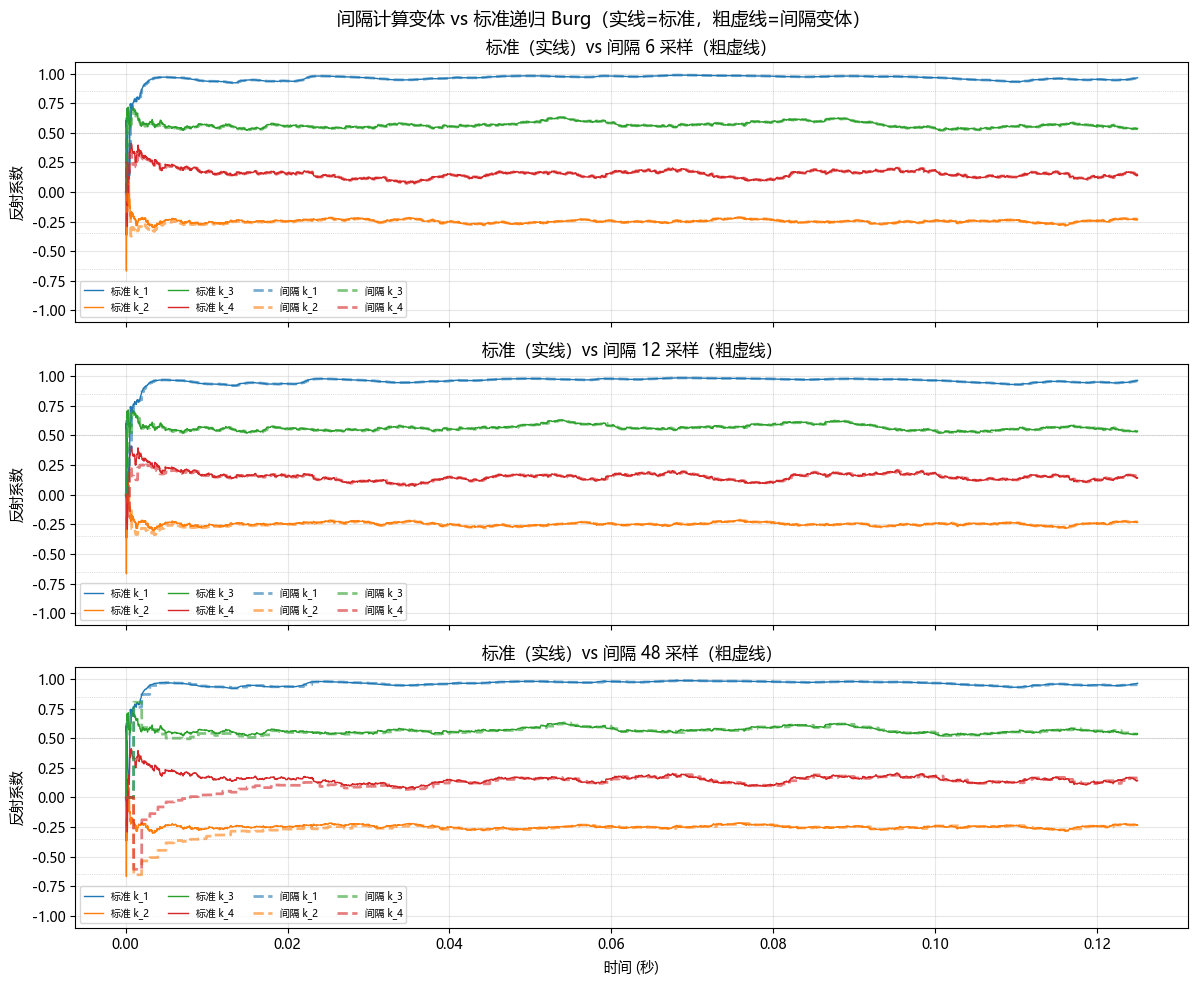

标准递归 Burg 稳态 RMSE: 0.329567
间隔 6 采样: 稳态 RMSE = 0.329457
间隔 12 采样: 稳态 RMSE = 0.329389
间隔 48 采样: 稳态 RMSE = 0.328576


In [19]:
# ------------------------------------------------------------
# 1a. 间隔计算 vs 标准递归 Burg
# ------------------------------------------------------------
tau = 0.010
lam = np.exp(-1.0 / (tau * fs_sim))

# 标准（逐采样更新）
k_std, e_std = recursive_burg(ar_pre, P, lam=lam)

# 要对比的间隔
intervals = [6, 12, 48]  # 采样点间隔

fig, axes = plt.subplots(len(intervals), 1, figsize=(12, 10), sharex=True)

for i, interval in enumerate(intervals):
    k_int, e_int = recursive_burg_interval(ar_pre, P, lam=lam, update_interval=interval)
    ax = axes[i]

    # 标准递归 Burg（实线，较细）
    for m in range(P):
        ax.plot(t_sim, k_std[:, m], linewidth=1.0, color=f'C{m}', label=f'标准 k_{m+1}')
    # 间隔变体（粗虚线，方便区分）
    for m in range(P):
        ax.plot(t_sim, k_int[:, m], linewidth=2.0, color=f'C{m}', linestyle='--', alpha=0.6, label=f'间隔 k_{m+1}')

    # 真实值水平线
    for m in range(P):
        ax.axhline(y=true_k[m], color='gray', linewidth=0.5, linestyle=':', alpha=0.5)

    ax.set_ylabel('反射系数')
    ax.set_title(f'标准（实线）vs 间隔 {interval} 采样（粗虚线）')
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=7, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle('间隔计算变体 vs 标准递归 Burg（实线=标准，粗虚线=间隔变体）', fontsize=13)
plt.tight_layout()
plt.show()

# 定量对比：稳态 RMSE
steady_start = int(0.05 * fs_sim)
k_true_mat = np.tile(true_k, (N_sim - steady_start, 1))
rmse_std = np.sqrt(np.mean((k_std[steady_start:] - k_true_mat)**2))
print(f"标准递归 Burg 稳态 RMSE: {rmse_std:.6f}")
for interval in intervals:
    k_int, _ = recursive_burg_interval(ar_pre, P, lam=lam, update_interval=interval)
    rmse_int = np.sqrt(np.mean((k_int[steady_start:] - k_true_mat)**2))
    print(f"间隔 {interval} 采样: 稳态 RMSE = {rmse_int:.6f}")

---
# 2. 矩形窗（CIC 形式）变体对比

用滑动矩形窗替代指数遗忘，通过积分-梳齿结构实现 O(1) 更新。
需要为每级每时间步保存前 L 个 f/b 值（环形缓冲），内存开销 O(P×L)。


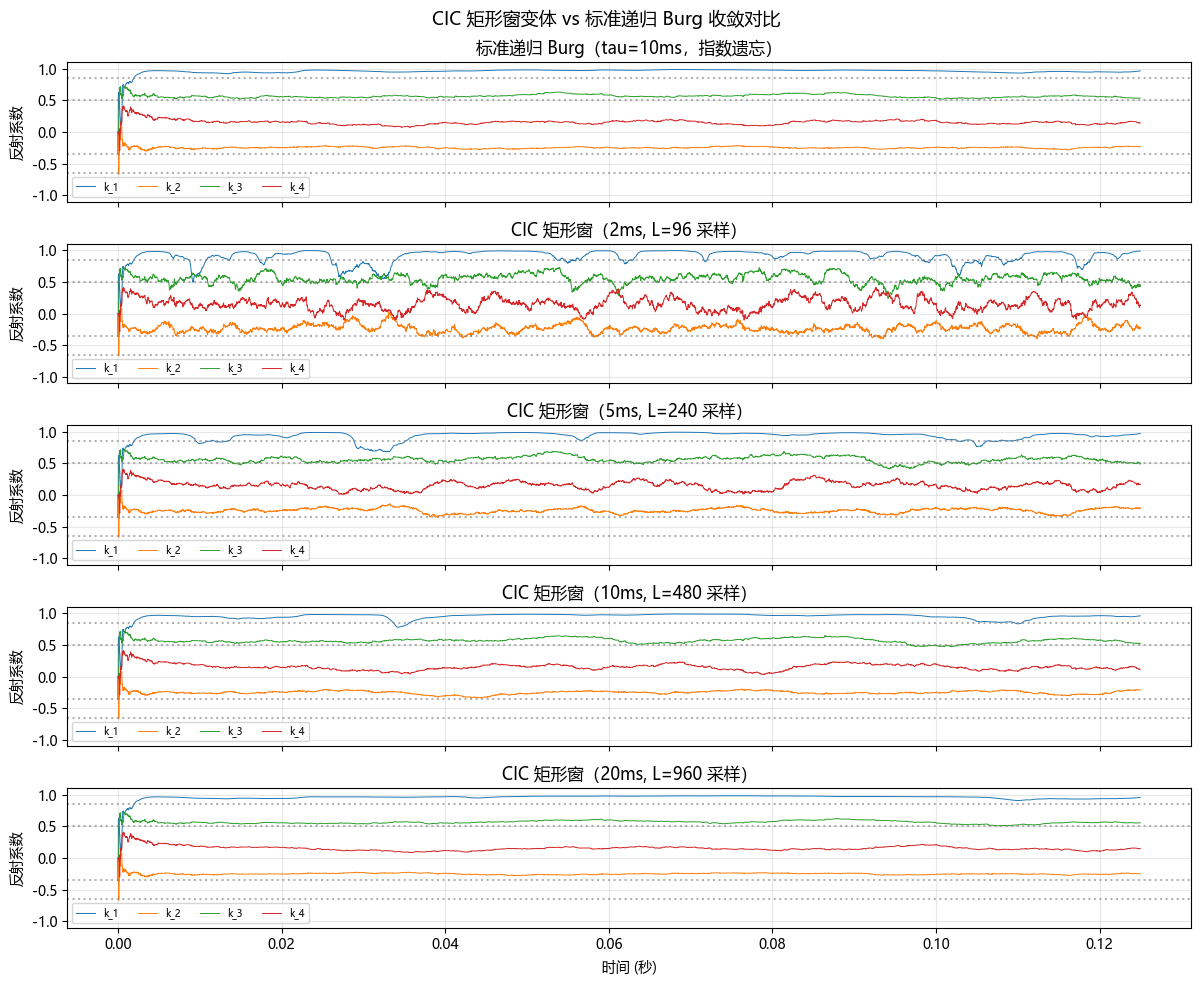

In [10]:
# ------------------------------------------------------------
# 2a. CIC 变体 vs 标准递归 Burg（等效窗长）
# ------------------------------------------------------------
# 标准递归 Burg 的有效记忆 ≈ 1/(1-lam) 采样点
# CIC 变体用相同的窗长
window_ms_list = [2, 5, 10, 20]  # 矩形窗长度 (ms)

fig, axes = plt.subplots(len(window_ms_list) + 1, 1, figsize=(12, 10), sharex=True)

# 子图 0：标准递归 Burg（tau=10ms 作参考）
ax = axes[0]
k_std_ref, _ = recursive_burg(ar_pre, P, lam=np.exp(-1.0/(0.010*fs_sim)))
for m in range(P):
    ax.plot(t_sim, k_std_ref[:, m], linewidth=0.7, label=f'k_{m+1}')
for m in range(P):
    ax.axhline(y=true_k[m], color='gray', ls=':', alpha=0.6)
ax.set_ylabel('反射系数')
ax.set_title('标准递归 Burg（tau=10ms，指数遗忘）')
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=7, ncol=4)
ax.grid(True, alpha=0.3)

# 子图 1~4：CIC 变体（不同矩形窗长）
for i, w_ms in enumerate(window_ms_list):
    w_len = int(w_ms * fs_sim / 1000)
    k_cic, e_cic = recursive_burg_cic(ar_pre, P, window_len=w_len)
    ax = axes[i + 1]
    for m in range(P):
        ax.plot(t_sim, k_cic[:, m], linewidth=0.7, label=f'k_{m+1}')
    for m in range(P):
        ax.axhline(y=true_k[m], color='gray', ls=':', alpha=0.6)
    ax.set_ylabel('反射系数')
    ax.set_title(f'CIC 矩形窗（{w_ms}ms, L={w_len} 采样）')
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=7, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle('CIC 矩形窗变体 vs 标准递归 Burg 收敛对比', fontsize=13)
plt.tight_layout()
plt.show()

---
# 3. 综合对比：三种方法的残差与频谱包络

在相同等效记忆长度下比较标准递归 Burg、间隔变体、CIC 变体三种方法的 LPC 频谱包络和残差。

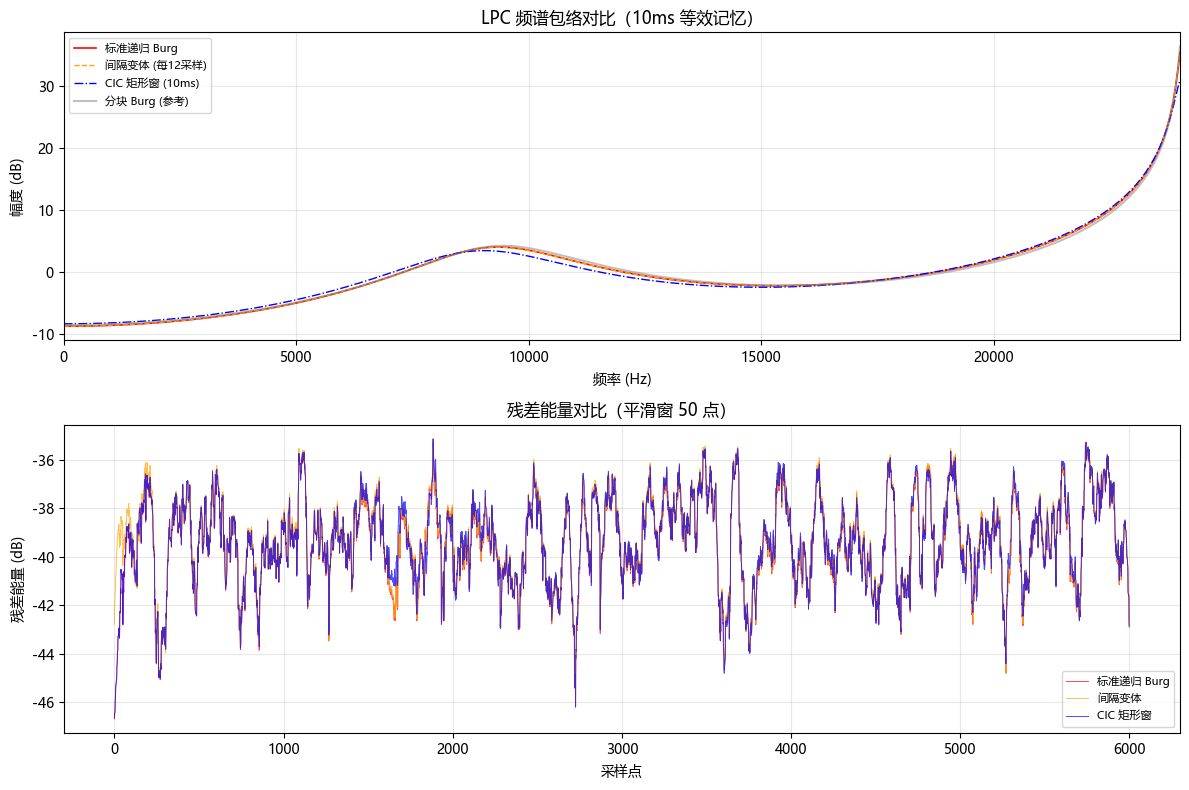

残差总能量:
  标准递归 Burg: 65.875740
  间隔变体:      66.884243
  CIC 矩形窗:    66.303910
  分块 Burg:     66.371401


In [12]:
# ------------------------------------------------------------
# 3. 综合对比：频谱包络与残差
# ------------------------------------------------------------
equiv_mem_ms = 10
equiv_mem_len = int(equiv_mem_ms * fs_sim / 1000)

lam_equiv = np.exp(-1.0 / (equiv_mem_ms / 1000 * fs_sim))
k_std_cmp, e_std_cmp = recursive_burg(ar_pre, P, lam=lam_equiv)
k_int_cmp, e_int_cmp = recursive_burg_interval(ar_pre, P, lam=lam_equiv, update_interval=12)
k_cic_cmp, e_cic_cmp = recursive_burg_cic(ar_pre, P, window_len=equiv_mem_len)
a_block_ref, e_block_ref, k_block_ref = block_burg(ar_pre, P)

n_fft_env = 1024
n_freqs = n_fft_env // 2 + 1

def lpc_spec(k_vec, n_freqs, fs=fs_sim):
    a = levinson_from_k(k_vec)
    w, h = freqz(1.0, a, worN=n_freqs, fs=fs)
    return w, 20 * np.log10(np.abs(h) + 1e-30)

freq_axis = np.linspace(0, fs_sim / 2, n_freqs)
steady_t = int(0.1 * fs_sim)

w_env, env_std = lpc_spec(k_std_cmp[steady_t], n_freqs)
_, env_int = lpc_spec(k_int_cmp[steady_t], n_freqs)
_, env_cic = lpc_spec(k_cic_cmp[steady_t], n_freqs)
_, env_block = lpc_spec(k_block_ref, n_freqs)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax1 = axes[0]
ax1.plot(freq_axis, env_std, 'r-', linewidth=1.2, label='标准递归 Burg')
ax1.plot(freq_axis, env_int, color='orange', linewidth=1.0, linestyle='--', label='间隔变体 (每12采样)')
ax1.plot(freq_axis, env_cic, color='blue', linewidth=1.0, linestyle='-.', label='CIC 矩形窗 (10ms)')
ax1.plot(freq_axis, env_block, 'gray', linewidth=1.5, alpha=0.5, label='分块 Burg (参考)')
ax1.set_xlabel('频率 (Hz)')
ax1.set_ylabel('幅度 (dB)')
ax1.set_title(f'LPC 频谱包络对比（{equiv_mem_ms}ms 等效记忆）')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, fs_sim / 2)

ax2 = axes[1]
win_smooth = 50
ax2.plot(20*np.log10(np.convolve(e_std_cmp**2, np.ones(win_smooth)/win_smooth, mode='same') + 1e-30),
         'r-', linewidth=0.7, alpha=0.7, label='标准递归 Burg')
ax2.plot(20*np.log10(np.convolve(e_int_cmp**2, np.ones(win_smooth)/win_smooth, mode='same') + 1e-30),
         color='orange', linewidth=0.7, alpha=0.7, label='间隔变体')
ax2.plot(20*np.log10(np.convolve(e_cic_cmp**2, np.ones(win_smooth)/win_smooth, mode='same') + 1e-30),
         color='blue', linewidth=0.7, alpha=0.7, label='CIC 矩形窗')
ax2.set_xlabel('采样点')
ax2.set_ylabel('残差能量 (dB)')
ax2.set_title('残差能量对比（平滑窗 50 点）')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"残差总能量:")
print(f"  标准递归 Burg: {np.sum(e_std_cmp**2):.6f}")
print(f"  间隔变体:      {np.sum(e_int_cmp**2):.6f}")
print(f"  CIC 矩形窗:    {np.sum(e_cic_cmp**2):.6f}")
print(f"  分块 Burg:     {np.sum(e_block_ref**2):.6f}")

---
# 4. 更多变体探索

尝试以下三种新变体，与标准递归 Burg 和分块 Burg 对比。

## 变体说明

| 变体 | 核心思路 | 预期特点 |
|------|---------|---------|
| **Sign-Burg** | $A_m(t) = \lambda A_m(t-1) + \operatorname{sgn}(f) \cdot \operatorname{sgn}(b)$ | 仅用符号更新，抗野值、计算量极低 |
| **NLMS 格型** | $k_m(t) = k_m(t-1) - \mu \frac{f_m(t) b_{m-1}(t-1) + b_m(t) f_{m-1}(t)}{P_m(t) + \varepsilon}$ | 固定步长、功率归一化，类似 NLMS |
| **变遗忘因子** | $\lambda(t) = \lambda_\infty + (1-\lambda_\infty) \cdot e^{-\alpha \cdot \mathcal{E}(t)}$ | 误差大时快速跟踪，误差小时平滑 |

In [20]:
# ------------------------------------------------------------
# 变体三：Sign-Burg（仅符号更新 A_m）
# ------------------------------------------------------------
def recursive_burg_sign(x, order, lam=0.995, eps=1e-6):
    """
    与标准递归 Burg 相同，但 A_m 更新使用符号乘积 sgn(f)*sgn(b) 替代 f*b。
    这等价于用 ±1 幅度更新，对野值更鲁棒。
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            # 符号乘积更新
            A[m] = lam * A[m] + np.sign(f_m1_t) * np.sign(b_m1_t1)
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

In [21]:
# ------------------------------------------------------------
# 变体四：NLMS 风格格型（固定步长梯度下降）
# ------------------------------------------------------------
def recursive_burg_nlms(x, order, mu=0.01, eps=1e-6):
    """
    用 NLMS 风格的梯度下降替代 RLS 累积量更新。

    格型滤波器目标函数对 k_m 的梯度：
        dJ/dk_m = 2 * (f_m[t] * b_{m-1}[t-1] + b_m[t] * f_{m-1}[t])
    
    用瞬时梯度 + 功率归一化步长：
        k_m(t) = k_m(t-1) - mu * (f_m[t]*b_{m-1}[t-1] + b_m[t]*f_{m-1}[t])
                          / (P_m(t) + eps)
    
    其中 P_m(t) 是 f^2 + b^2 的指数平滑估计。
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    P = np.full(order, eps, dtype=dtype)  # 功率估计
    lam_p = 0.9  # 功率平滑系数
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            
            # 先用当前 k 传播
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
            
            # 瞬时梯度
            grad = f_curr[m + 1] * b_m1_t1 + b_curr[m + 1] * f_m1_t
            
            # 功率估计
            P[m] = lam_p * P[m] + (1 - lam_p) * (f_m1_t**2 + b_m1_t1**2)
            
            # 梯度下降更新
            k[m] -= mu * grad / (P[m] + eps)
            k[m] = np.clip(k[m], -0.999, 0.999)
            
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

In [22]:
# ------------------------------------------------------------
# 变体五：变遗忘因子递归 Burg
# ------------------------------------------------------------
def recursive_burg_var_lam(x, order, lam_inf=0.99, lam_0=0.8, alpha=50.0, eps=1e-6):
    """
    遗忘因子随预测误差能量自适应变化。

    当误差能量大（信号突变/未收敛）→ λ 变小 → 快速跟踪
    当误差能量小（稳态）→ λ → lam_inf → 平滑估计

    lambda(t) = lam_inf + (lam_0 - lam_inf) * exp(-alpha * E(t))
    其中 E(t) 是残差能量的指数平滑估计
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    
    # 对每级独立维护累积量（用变 λ）
    A_list = [np.zeros(order, dtype=dtype)]
    B_list = [np.full(order, eps, dtype=dtype)]
    lam_actual = lam_inf
    
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    lam_history = np.zeros(N, dtype=dtype)
    
    # 误差能量平滑估计
    err_power = 0.0
    lam_err = 0.95
    
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            
            # 用当前 λ 更新累积量
            A[m] = lam_actual * A[m] + f_m1_t * b_m1_t1
            B[m] = lam_actual * B[m] + f_m1_t**2 + b_m1_t1**2
            
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        
        # 更新误差能量估计
        err_power = lam_err * err_power + (1 - lam_err) * f_curr[order]**2
        
        # 根据误差能量调整 λ
        lam_actual = lam_inf + (lam_0 - lam_inf) * np.exp(-alpha * err_power)
        lam_actual = np.clip(lam_actual, lam_0, lam_inf)
        
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        lam_history[t] = lam_actual
        b_prev_arr[:order] = b_curr[:order]
    
    return k_history, e, lam_history

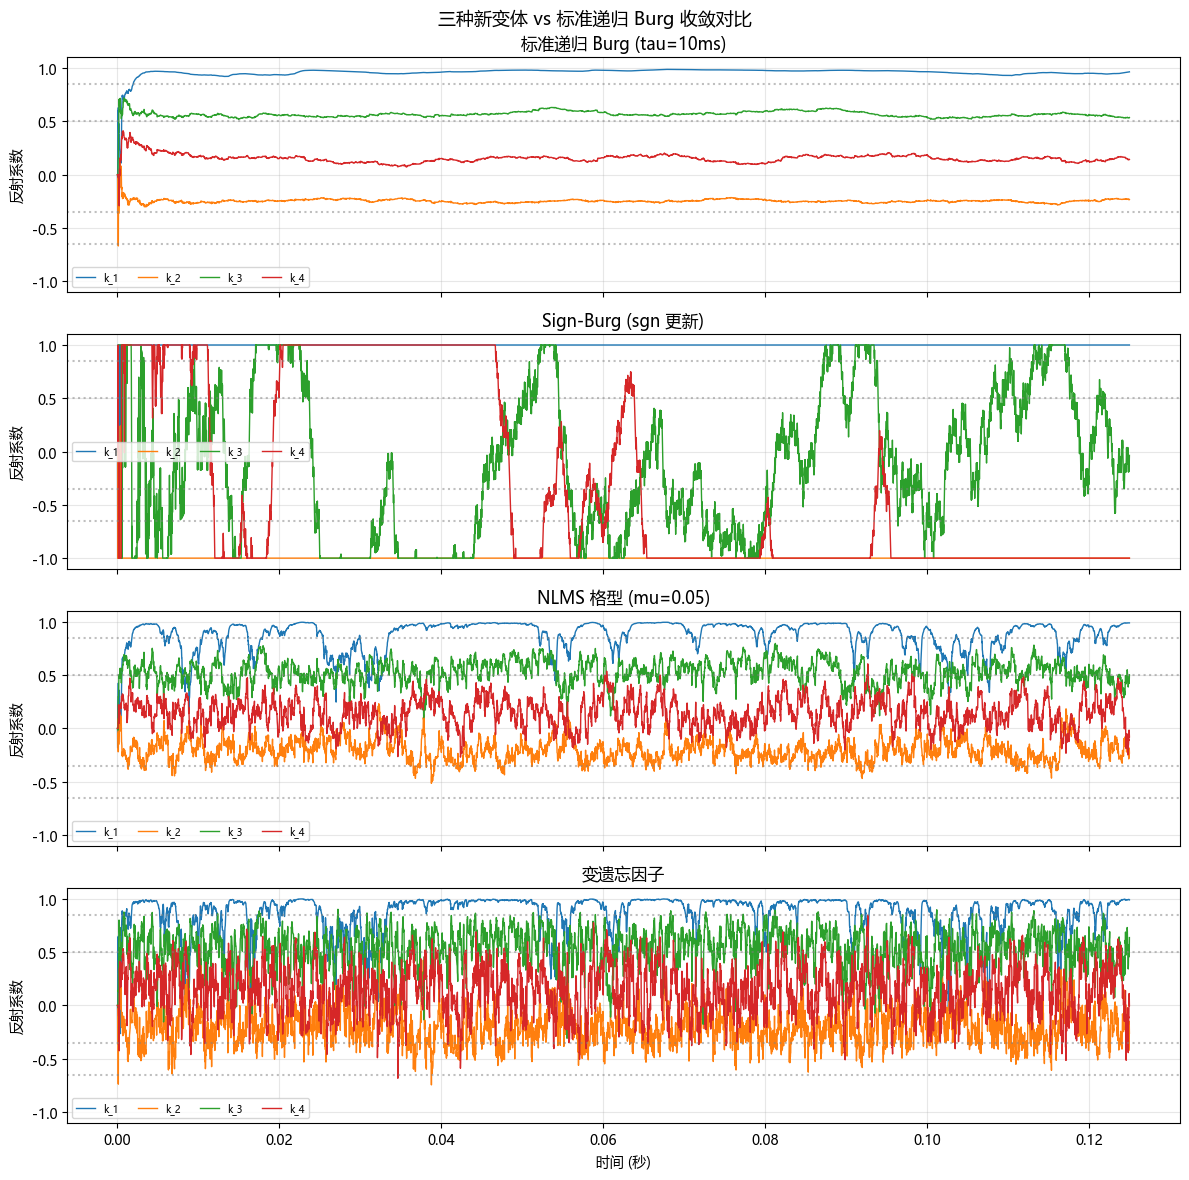

标准递归 Burg 稳态 RMSE: 0.329567
  Sign-Burg (sgn 更新): 稳态 RMSE = 0.535171
  NLMS 格型 (mu=0.05): 稳态 RMSE = 0.354043
  变遗忘因子: 稳态 RMSE = 0.382942


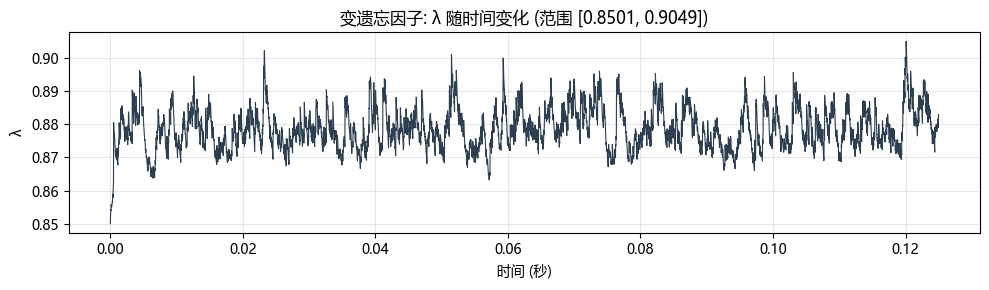

In [23]:
# ------------------------------------------------------------
# 4a. 三种新变体 vs 标准递归 Burg 对比
# ------------------------------------------------------------
tau_ref = 0.010
lam_ref = np.exp(-1.0 / (tau_ref * fs_sim))

# 标准
k_std_ref2, _ = recursive_burg(ar_pre, P, lam=lam_ref)

# Sign-Burg（与标准相同的 λ）
k_sign, e_sign = recursive_burg_sign(ar_pre, P, lam=lam_ref)

# NLMS 格型
k_nlms, e_nlms = recursive_burg_nlms(ar_pre, P, mu=0.05)

# 变遗忘因子
k_var, e_var, lam_hist = recursive_burg_var_lam(ar_pre, P, lam_inf=0.995, lam_0=0.85, alpha=30.0)

variants = {
    'Sign-Burg (sgn 更新)': k_sign,
    'NLMS 格型 (mu=0.05)': k_nlms,
    '变遗忘因子': k_var,
}

fig, axes = plt.subplots(len(variants) + 1, 1, figsize=(12, 12), sharex=True)

# 子图 0：标准
ax = axes[0]
for m in range(P):
    ax.plot(t_sim, k_std_ref2[:, m], linewidth=1.0, label=f'k_{m+1}')
for m in range(P):
    ax.axhline(y=true_k[m], color='gray', ls=':', alpha=0.5)
ax.set_ylabel('反射系数')
ax.set_title('标准递归 Burg (tau=10ms)')
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=7, ncol=4)
ax.grid(True, alpha=0.3)

# 子图 1~3：各变体
for i, (name, k_var_data) in enumerate(variants.items()):
    ax = axes[i + 1]
    for m in range(P):
        ax.plot(t_sim, k_var_data[:, m], linewidth=1.0, label=f'k_{m+1}')
    for m in range(P):
        ax.axhline(y=true_k[m], color='gray', ls=':', alpha=0.5)
    ax.set_ylabel('反射系数')
    ax.set_title(name)
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=7, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle('三种新变体 vs 标准递归 Burg 收敛对比', fontsize=13)
plt.tight_layout()
plt.show()

# 稳态 RMSE
steady_start = int(0.05 * fs_sim)
k_true_mat2 = np.tile(true_k, (N_sim - steady_start, 1))
rmse_std2 = np.sqrt(np.mean((k_std_ref2[steady_start:] - k_true_mat2)**2))
print(f"标准递归 Burg 稳态 RMSE: {rmse_std2:.6f}")
for name, k_var_data in variants.items():
    rmse = np.sqrt(np.mean((k_var_data[steady_start:] - k_true_mat2)**2))
    print(f"  {name}: 稳态 RMSE = {rmse:.6f}")

# 变遗忘因子的 λ 变化
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_sim, lam_hist, linewidth=0.8, color='#2c3e50')
ax.set_xlabel('时间 (秒)')
ax.set_ylabel('λ')
ax.set_title(f'变遗忘因子: λ 随时间变化 (范围 [{lam_hist.min():.4f}, {lam_hist.max():.4f}])')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 5. 稳定性优化变体

针对反射系数 k 波动大的问题，借鉴已有信号处理技术设计以下变体。

| 变体 | 技术来源 | 核心思路 |
|------|---------|---------|
| **动量 Burg** | Adam / 梯度下降动量 | $k_m(t) = k_m(t-1) + \text{momentum}$ 平滑更新方向 |
| **岭回归 Burg** | 正则化最小二乘 | $B_m += \delta$ 防止除零放大噪声 |
| **双时间尺度 Burg** | 分离估计与传播 | 快 λ 格型传播 + 慢 λ 累积量估计 |
| **中值滤波 Burg** | 非线性滤波 | 对 k 的短时估计做滑动中值滤波 |
| **自适应 NLMS** | 梯度符号一致性 | 梯度方向一致时增大步长，震荡时减小 |

In [24]:
# ------------------------------------------------------------
# 变体六：动量 Burg（梯度下降动量平滑）
# ------------------------------------------------------------
def recursive_burg_momentum(x, order, lam=0.995, mu=0.3, beta=0.8, eps=1e-6):
    """
    在标准递归 Burg 的 RLS 更新上叠加动量项。
    k_m 的每次更新不仅依赖当前 A_m/B_m，还叠加历史更新方向。
    
    k_raw = -2*A/B
    k_m = k_m + mu * (k_raw - k_m) + beta * (k_m - k_m_prev)  # 含动量
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_prev = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k_raw = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k_raw = np.clip(k_raw, -0.999, 0.999)
            # 动量更新
            k_new = k[m] + mu * (k_raw - k[m]) + beta * (k[m] - k_prev[m])
            k_prev[m] = k[m]
            k[m] = np.clip(k_new, -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

# ------------------------------------------------------------
# 变体七：岭回归 Burg（正则化分母）
# ------------------------------------------------------------
def recursive_burg_ridge(x, order, lam=0.995, delta=0.1, eps=1e-6):
    """
    在 B_m 上叠加正则化项 delta，防止分母过小导致 k 的噪声放大。
    k_m = -2 * A_m / (B_m + delta)
    类似于岭回归 / 对角加载技术。
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / (B[m] + delta) if B[m] + delta > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

# ------------------------------------------------------------
# 变体八：双时间尺度 Burg
# ------------------------------------------------------------
def recursive_burg_dual(x, order, lam_fast=0.95, lam_slow=0.998, eps=1e-6):
    """
    快 λ（lam_fast）用于格型传播（前向/后向误差更新）。
    慢 λ（lam_slow）用于累积量 A_m/B_m 估计。
    
    这样可以在保持格型快速响应的同时，让 k 的估计更平滑。
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    # 累积量用慢 λ
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    # 格型用快 λ（额外的累积量）
    A_fast = np.zeros(order, dtype=dtype)
    B_fast = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            # 慢 λ 累积量（k 的估计）
            A[m] = lam_slow * A[m] + f_m1_t * b_m1_t1
            B[m] = lam_slow * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            # 快 λ 格型传播
            A_fast[m] = lam_fast * A_fast[m] + f_m1_t * b_m1_t1
            B_fast[m] = lam_fast * B_fast[m] + f_m1_t**2 + b_m1_t1**2
            k_fast = -2.0 * A_fast[m] / B_fast[m] if B_fast[m] > 1e-30 else 0.0
            k_fast = np.clip(k_fast, -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k_fast * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k_fast * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

# ------------------------------------------------------------
# 变体九：中值滤波 Burg
# ------------------------------------------------------------
def recursive_burg_median(x, order, lam=0.995, median_len=11, eps=1e-6):
    """
    标准递归 Burg 计算原始 k，然后对 k 的短时估计做滑动中值滤波。
    中值滤波能有效去除脉冲噪声，同时保留边缘。
    
    使用 deque 维护滑动窗口，每次取中值。
    """
    from collections import deque
    
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    
    # 每级维护一个滑动窗口
    windows = [deque(maxlen=median_len) for _ in range(order)]
    
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k_raw = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k_raw = np.clip(k_raw, -0.999, 0.999)
            
            # 中值滤波
            windows[m].append(k_raw)
            k_m = np.median(list(windows[m]))
            k[m] = k_m
            
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

# ------------------------------------------------------------
# 变体十：自适应步长 NLMS（梯度符号一致性）
# ------------------------------------------------------------
def recursive_burg_adanlms(x, order, mu_0=0.01, eps=1e-6):
    """
    改进 NLMS 格型：根据梯度符号一致性自适应调整步长。
    
    如果连续多次梯度方向一致 → 增大步长加速收敛
    如果梯度频繁震荡 → 减小步长提高稳定性
    
    类似于 AdaDelta / 符号一致性自适应。
    """
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    P = np.full(order, eps, dtype=dtype)
    lam_p = 0.9
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    
    # 符号一致性计数器
    sign_consistency = np.zeros(order, dtype=dtype)
    mu = np.full(order, mu_0, dtype=dtype)
    mu_max = 0.1
    mu_min = 0.001
    
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
            
            grad = f_curr[m + 1] * b_m1_t1 + b_curr[m + 1] * f_m1_t
            
            P[m] = lam_p * P[m] + (1 - lam_p) * (f_m1_t**2 + b_m1_t1**2)
            
            # 符号一致性检测
            if t > 0:
                same_sign = (grad * k_history[t-1, m]) > 0
                sign_consistency[m] = 0.9 * sign_consistency[m] + 0.1 * same_sign
            
            # 自适应步长：一致性高 → 大步长
            mu[m] = mu_0 + (mu_max - mu_0) * sign_consistency[m]
            mu[m] = np.clip(mu[m], mu_min, mu_max)
            
            k[m] -= mu[m] * grad / (P[m] + eps)
            k[m] = np.clip(k[m], -0.999, 0.999)
            
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

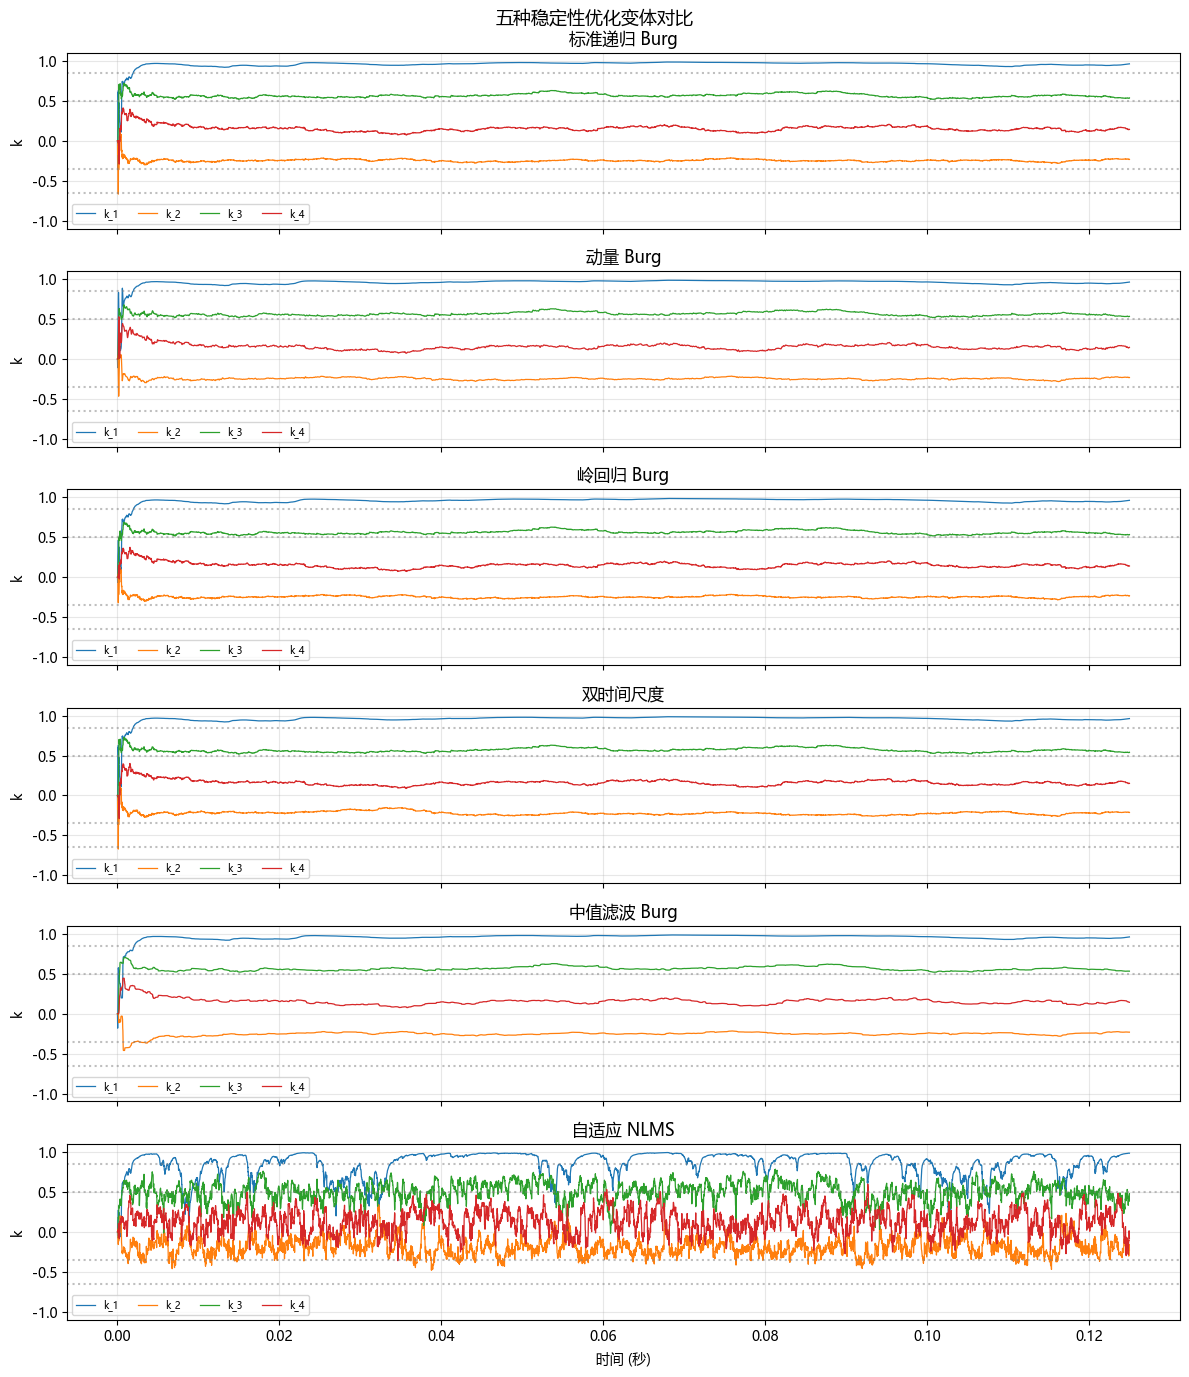

方法                 RMSE       k_std(波动)   
------------------------------------------
标准递归 Burg          0.329567   0.019376    
动量 Burg            0.329562   0.019400    
岭回归 Burg           0.329410   0.019356    
双时间尺度              0.338173   0.019940    
中值滤波 Burg          0.329334   0.019296    
自适应 NLMS           0.357030   0.128005    


In [25]:
# ------------------------------------------------------------
# 5a. 五种稳定性优化变体对比
# ------------------------------------------------------------
tau_ref3 = 0.010
lam_ref3 = np.exp(-1.0 / (tau_ref3 * fs_sim))

k_std3, _ = recursive_burg(ar_pre, P, lam=lam_ref3)
k_mom, e_mom = recursive_burg_momentum(ar_pre, P, lam=lam_ref3, mu=0.3, beta=0.7)
k_ridge, e_ridge = recursive_burg_ridge(ar_pre, P, lam=lam_ref3, delta=0.05)
k_dual, e_dual = recursive_burg_dual(ar_pre, P, lam_fast=0.95, lam_slow=0.998)
k_med, e_med = recursive_burg_median(ar_pre, P, lam=lam_ref3, median_len=15)
k_adp, e_adp = recursive_burg_adanlms(ar_pre, P, mu_0=0.02)

stab_variants = {
    '标准递归 Burg': k_std3,
    '动量 Burg': k_mom,
    '岭回归 Burg': k_ridge,
    '双时间尺度': k_dual,
    '中值滤波 Burg': k_med,
    '自适应 NLMS': k_adp,
}

fig, axes = plt.subplots(len(stab_variants), 1, figsize=(12, 14), sharex=True)

for i, (name, k_data) in enumerate(stab_variants.items()):
    ax = axes[i]
    for m in range(P):
        ax.plot(t_sim, k_data[:, m], linewidth=0.9, label=f'k_{m+1}')
    for m in range(P):
        ax.axhline(y=true_k[m], color='gray', ls=':', alpha=0.5)
    ax.set_ylabel('k')
    ax.set_title(name)
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=7, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle('五种稳定性优化变体对比', fontsize=13)
plt.tight_layout()
plt.show()

# RMSE + 波动性指标
steady_start3 = int(0.05 * fs_sim)
k_true_mat3 = np.tile(true_k, (N_sim - steady_start3, 1))
print(f"{'方法':<18} {'RMSE':<10} {'k_std(波动)':<12}")
print("-" * 42)
for name, k_data in stab_variants.items():
    rmse_v = np.sqrt(np.mean((k_data[steady_start3:] - k_true_mat3)**2))
    k_fluct = np.mean(np.std(k_data[steady_start3:], axis=0))
    print(f"{name:<18} {rmse_v:<10.6f} {k_fluct:<12.6f}")

---
# 5b. 时变信号下的稳定性对比

用时变 AR(2) 信号（中点参数突变）测试各变体的跟踪速度与稳态波动。

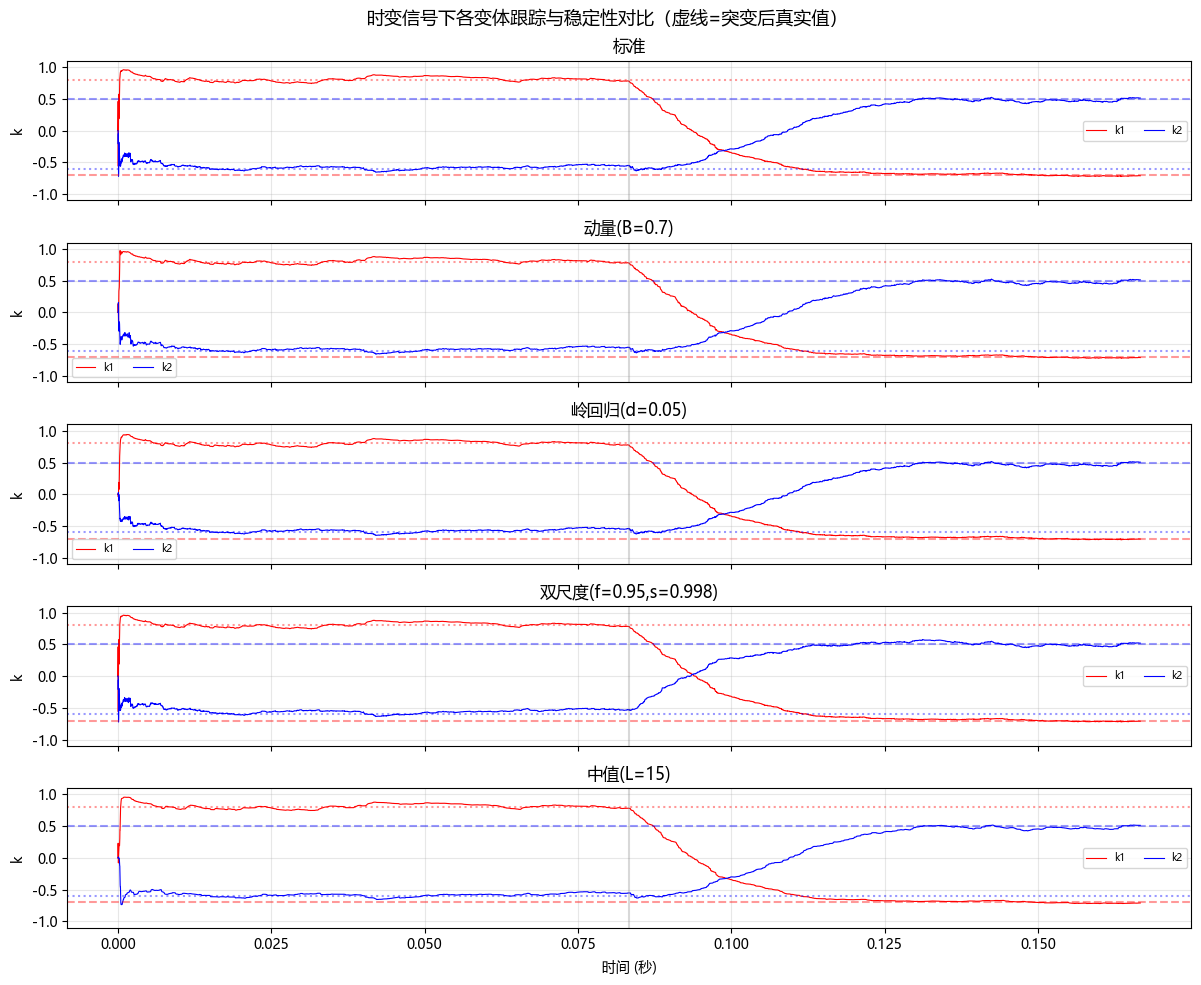

方法                       RMSE(突变后)      k_std(波动)    收敛(ms)    
--------------------------------------------------------------
标准                       0.170899       0.125479     46.2      
动量(B=0.7)                0.171293       0.125613     46.2      
岭回归(d=0.05)              0.172486       0.123964     46.5      
双尺度(f=0.95,s=0.998)      0.069035       0.061163     40.2      
中值(L=15)                 0.176287       0.128581     46.3      


In [26]:
# ------------------------------------------------------------
# 5b. 时变 AR(2) 信号下的稳定性与跟踪对比
# ------------------------------------------------------------
N_tv2 = 8000
sp2 = N_tv2 // 2

k1_tv = np.array([0.80, -0.60])
k2_tv = np.array([-0.70, 0.50])
a1_tv = levinson_from_k(k1_tv)
a2_tv = levinson_from_k(k2_tv)

wgn_tv = np.random.randn(N_tv2 + 50) * 0.05
ar1_tv = lfilter([1.0], a1_tv, wgn_tv[:sp2 + 50])[50:]
ar2_tv = lfilter([1.0], a2_tv, wgn_tv[sp2:])[50:]
ar_tv2 = np.concatenate([ar1_tv, ar2_tv])
t_tv2 = np.arange(N_tv2) / fs_sim

P_tv2 = 2
lam_tv2 = np.exp(-1.0 / (0.010 * fs_sim))

tv_variants = {
    '标准': lambda: recursive_burg(ar_tv2, P_tv2, lam=lam_tv2)[0],
    '动量(B=0.7)': lambda: recursive_burg_momentum(ar_tv2, P_tv2, lam=lam_tv2, mu=0.3, beta=0.7)[0],
    '岭回归(d=0.05)': lambda: recursive_burg_ridge(ar_tv2, P_tv2, lam=lam_tv2, delta=0.05)[0],
    '双尺度(f=0.95,s=0.998)': lambda: recursive_burg_dual(ar_tv2, P_tv2, lam_fast=0.95, lam_slow=0.998)[0],
    '中值(L=15)': lambda: recursive_burg_median(ar_tv2, P_tv2, lam=lam_tv2, median_len=15)[0],
}

fig, axes = plt.subplots(len(tv_variants), 1, figsize=(12, 10), sharex=True)

for i, (name, fn) in enumerate(tv_variants.items()):
    k_tv = fn()
    ax = axes[i]
    ax.plot(t_tv2, k_tv[:, 0], 'r-', linewidth=0.8, label='k1')
    ax.plot(t_tv2, k_tv[:, 1], 'b-', linewidth=0.8, label='k2')
    ax.axhline(k1_tv[0], color='r', ls=':', alpha=0.4)
    ax.axhline(k1_tv[1], color='b', ls=':', alpha=0.4)
    ax.axhline(k2_tv[0], color='r', ls='--', alpha=0.4)
    ax.axhline(k2_tv[1], color='b', ls='--', alpha=0.4)
    ax.axvline(sp2 / fs_sim, color='gray', ls='-', alpha=0.3)
    ax.set_ylabel('k')
    ax.set_title(name)
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle('时变信号下各变体跟踪与稳定性对比（虚线=突变后真实值）', fontsize=13)
plt.tight_layout()
plt.show()

# 突变后收敛时间与稳态波动
after_sp = int(sp2 + 0.02 * fs_sim)  # 突变后 20ms
k_true_after = np.tile(k2_tv, (N_tv2 - after_sp, 1))

print(f"{'方法':<24} {'RMSE(突变后)':<14} {'k_std(波动)':<12} {'收敛(ms)':<10}")
print("-" * 62)
for name, fn in tv_variants.items():
    k_tv = fn()
    rmse_a = np.sqrt(np.mean((k_tv[after_sp:] - k_true_after)**2))
    k_fl = np.mean(np.std(k_tv[after_sp:], axis=0))
    # 估计收敛时间：k 进入真实值 ±5% 范围
    settle = N_tv2
    for n in range(sp2, N_tv2):
        if np.all(np.abs(k_tv[n] - k2_tv) < 0.05 * np.abs(k2_tv)):
            settle = n
            break
    settle_ms = (settle - sp2) / fs_sim * 1000
    print(f"{name:<24} {rmse_a:<14.6f} {k_fl:<12.6f} {settle_ms:<10.1f}")

---
# 6. 真实音频测试：wormhole.wav

使用 wormhole.wav 前 1 秒的人声信号，测试所有变体的残差能量、LPC 包络与自相关白化效果。

In [27]:
# ------------------------------------------------------------
# 6a. 加载 wormhole.wav 前 1 秒
# ------------------------------------------------------------
import soundfile as sf
import os

WAV_PATH = r"c:\Users\Kawai\Desktop\a5632645\qwqdsp\qwqdsp\tests\work_dir\input\wormhole.wav"
x_full_real, fs_real = sf.read(WAV_PATH)
if x_full_real.ndim > 1:
    x_full_real = x_full_real[:, 0]

# 取前 1 秒
N_real = int(1.0 * fs_real)
x_real = x_full_real[:N_real].copy()
t_real = np.arange(N_real) / fs_real

# 预加重
pre_emph = 0.97
x_real_pre = np.append(x_real[0], x_real[1:] - pre_emph * x_real[:-1])

P_real = 16  # 人声用 16 阶
print(f"采样率: {fs_real} Hz, 长度: {N_real} 样本 ({N_real/fs_real:.2f} 秒)")
print(f"信号范围: [{x_real.min():.4f}, {x_real.max():.4f}]")

采样率: 48000 Hz, 长度: 48000 样本 (1.00 秒)
信号范围: [-0.5369, 0.4222]


In [28]:
# ------------------------------------------------------------
# 6b. 所有变体处理真实音频
# ------------------------------------------------------------
from IPython.display import Audio

lam_real = np.exp(-1.0 / (0.010 * fs_real))

# 收集所有变体
all_variants = {}

# 标准 & 基础变体
all_variants['标准'] = lambda: recursive_burg(x_real_pre, P_real, lam=lam_real)
all_variants['间隔(48)'] = lambda: recursive_burg_interval(x_real_pre, P_real, lam=lam_real, update_interval=48)
all_variants['CIC(10ms)'] = lambda: recursive_burg_cic(x_real_pre, P_real, window_len=int(0.010 * fs_real))

# Section 4 变体
all_variants['Sign-Burg'] = lambda: recursive_burg_sign(x_real_pre, P_real, lam=lam_real)
all_variants['NLMS'] = lambda: recursive_burg_nlms(x_real_pre, P_real, mu=0.02)

# Section 5 变体
all_variants['动量'] = lambda: recursive_burg_momentum(x_real_pre, P_real, lam=lam_real, mu=0.3, beta=0.7)
all_variants['岭回归'] = lambda: recursive_burg_ridge(x_real_pre, P_real, lam=lam_real, delta=0.05)
all_variants['双尺度'] = lambda: recursive_burg_dual(x_real_pre, P_real, lam_fast=0.95, lam_slow=0.998)
all_variants['中值(L=15)'] = lambda: recursive_burg_median(x_real_pre, P_real, lam=lam_real, median_len=15)

# 分块 Burg 参考（逐帧）
frame_ms = 30
hop_ms = 10
frame_len = int(frame_ms * fs_real / 1000)
hop_len = int(hop_ms * fs_real / 1000)
n_frames = 1 + (N_real - frame_len) // hop_len
e_block_real = np.zeros(N_real)
win = np.hanning(frame_len)
for idx in range(n_frames):
    s = idx * hop_len
    frame = x_real_pre[s:s + frame_len] * win
    a_f, e_f, _ = block_burg(frame, P_real)
    e_block_real[s:s + frame_len] += e_f * win

# 运行所有变体
results = {}
print("运行变体中...")
for name, fn in all_variants.items():
    k_h, e_h = fn()
    results[name] = {'k': k_h, 'e': e_h}
    print(f"  {name}: 残差能量 = {np.sum(e_h**2):.4f}")

results['分块 Burg'] = {'k': None, 'e': e_block_real}
print(f"  分块 Burg: 残差能量 = {np.sum(e_block_real**2):.4f}")

# 归一化残差用于播放
for name in results:
    ee = results[name]['e']
    ee_max = np.max(np.abs(ee))
    results[name]['e_norm'] = ee / ee_max if ee_max > 1e-30 else ee

运行变体中...
  标准: 残差能量 = 0.0349
  间隔(48): 残差能量 = 0.0787
  CIC(10ms): 残差能量 = 0.0367
  Sign-Burg: 残差能量 = 2049.2924
  NLMS: 残差能量 = 0.1296
  动量: 残差能量 = 0.0309
  岭回归: 残差能量 = 0.9132
  双尺度: 残差能量 = 0.0591
  中值(L=15): 残差能量 = 0.0359
  分块 Burg: 残差能量 = 0.0252


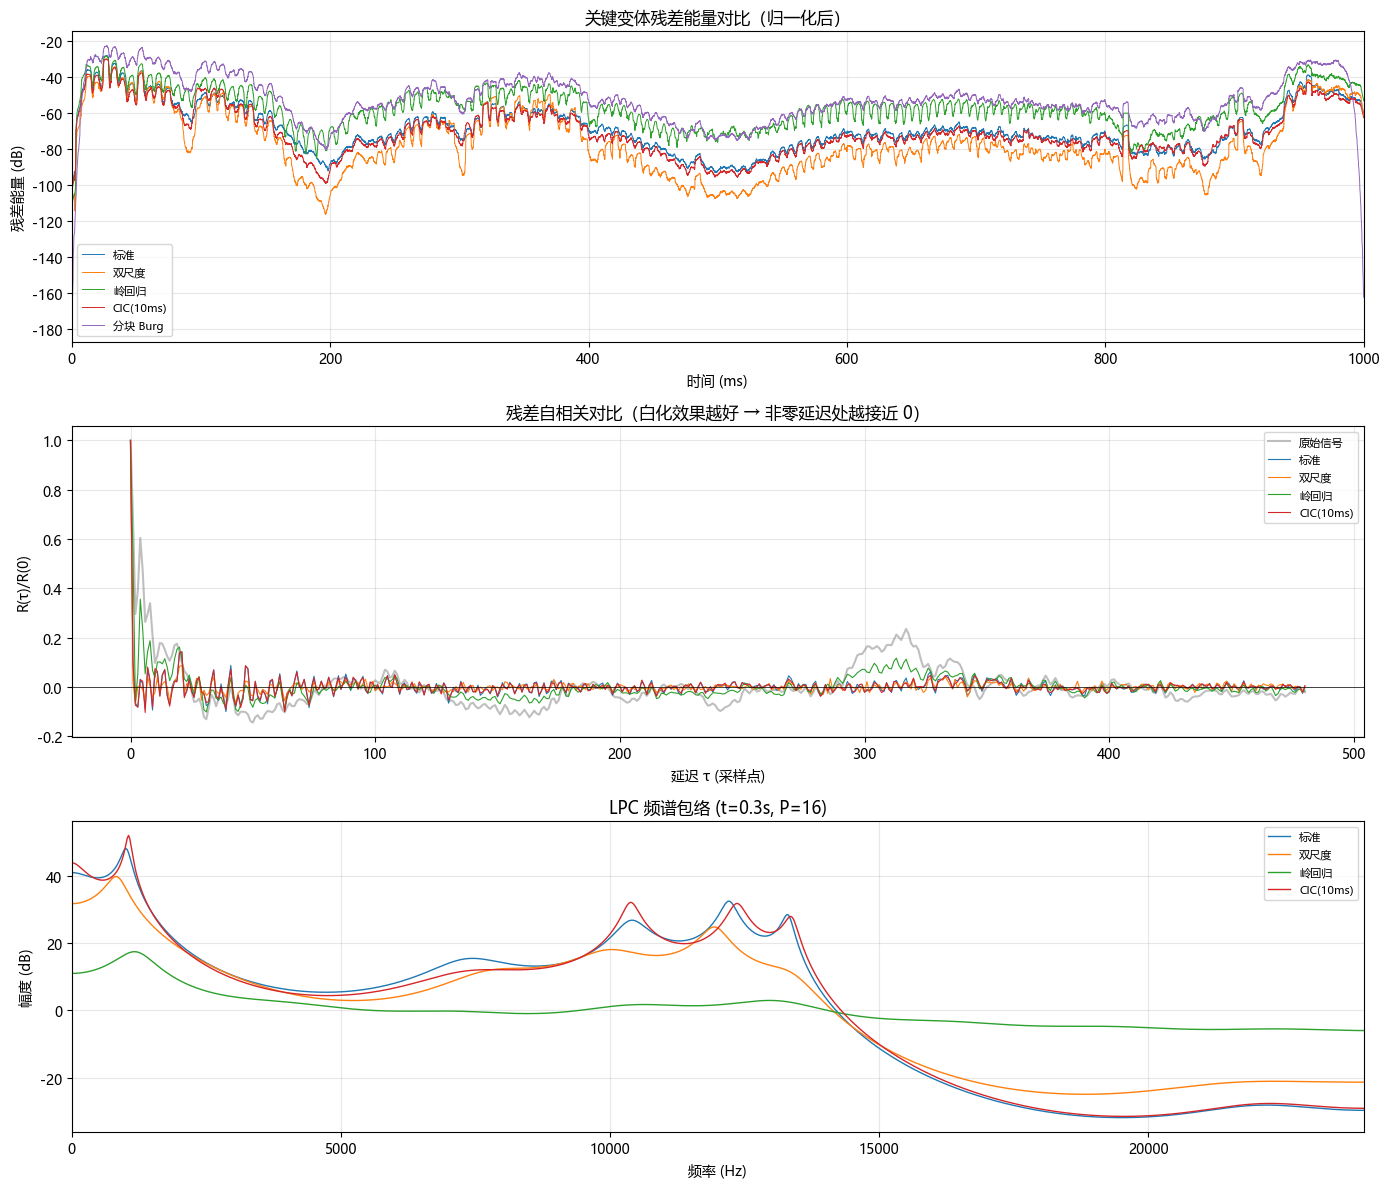

变体               残差能量         max|R(τ>0)|    残差能量(dB)    
--------------------------------------------------------
标准               0.034894     0.141816       -14.57      
间隔(48)           0.078736     0.330420       -11.04      
CIC(10ms)        0.036675     0.142636       -14.36      
Sign-Burg        2049.292435  0.884777       33.12       
NLMS             0.129583     0.344663       -8.87       
动量               0.030874     0.141785       -15.10      
岭回归              0.913168     0.539601       -0.39       
双尺度              0.059090     0.087651       -12.28      
中值(L=15)         0.035888     0.215801       -14.45      
分块 Burg          0.025214     0.149567       -15.98      

原始音频 (1秒):


标准 残差:


双尺度 残差:


CIC(10ms) 残差:


分块 Burg 残差:


In [29]:
# ------------------------------------------------------------
# 6c. 残差波形 + 自相关白化 + 频谱包络对比
# ------------------------------------------------------------
n_fft_real = 2048
n_freqs_real = n_fft_real // 2 + 1
freq_axis_real = np.linspace(0, fs_real / 2, n_freqs_real)

# 取稳态时刻的反射系数算 LPC 包络（约 0.3 秒处）
steady_idx = int(0.3 * fs_real)

def compute_envelopes(results, steady_idx):
    envs = {}
    for name, r in results.items():
        if r['k'] is not None and steady_idx < len(r['k']):
            a_env = levinson_from_k(r['k'][steady_idx])
            w_e, h_e = freqz(1.0, a_env, worN=n_freqs_real, fs=fs_real)
            envs[name] = 20 * np.log10(np.abs(h_e) + 1e-30)
    return envs

envs = compute_envelopes(results, steady_idx)

# 计算自相关
def norm_autocorr(signal, max_lag=480):
    r = np.correlate(signal, signal, mode='full')
    mid = len(r) // 2
    return r[mid:mid + max_lag + 1] / r[mid]

max_ac_lag = int(0.010 * fs_real)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 子图 1：残差能量对比（滑动平滑）
ax1 = axes[0]
win_s = 200
t_real_ms = t_real * 1000
for name in ['标准', '双尺度', '岭回归', 'CIC(10ms)', '分块 Burg']:
    if name not in results:
        continue
    ee = results[name]['e_norm']
    e_db = 20 * np.log10(np.convolve(ee**2, np.ones(win_s)/win_s, mode='same') + 1e-30)
    ax1.plot(t_real_ms, e_db, linewidth=0.7, label=name)
ax1.set_xlabel('时间 (ms)')
ax1.set_ylabel('残差能量 (dB)')
ax1.set_title('关键变体残差能量对比（归一化后）')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1000)

# 子图 2：自相关（白化效果）
ax2 = axes[1]
lags = np.arange(max_ac_lag + 1)
r_orig = norm_autocorr(x_real_pre, max_ac_lag)
ax2.plot(lags, r_orig, 'gray', linewidth=1.5, alpha=0.5, label='原始信号')
for name in ['标准', '双尺度', '岭回归', 'CIC(10ms)']:
    if name not in results:
        continue
    r_res = norm_autocorr(results[name]['e_norm'], max_ac_lag)
    ax2.plot(lags, r_res, linewidth=0.8, label=name)
ax2.axhline(0, color='black', lw=0.5)
ax2.set_xlabel('延迟 τ (采样点)')
ax2.set_ylabel('R(τ)/R(0)')
ax2.set_title('残差自相关对比（白化效果越好 → 非零延迟处越接近 0）')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 子图 3：LPC 频谱包络（0.3s 处）
ax3 = axes[2]
for name in ['标准', '双尺度', '岭回归', 'CIC(10ms)']:
    if name in envs:
        ax3.plot(freq_axis_real, envs[name], linewidth=1.0, label=name)
ax3.set_xlabel('频率 (Hz)')
ax3.set_ylabel('幅度 (dB)')
ax3.set_title(f'LPC 频谱包络 (t=0.3s, P={P_real})')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, fs_real / 2)

plt.tight_layout()
plt.show()

# 定量汇总
print(f"{'变体':<16} {'残差能量':<12} {'max|R(τ>0)|':<14} {'残差能量(dB)':<12}")
print("-" * 56)
r_orig_max = np.max(np.abs(r_orig[1:]))
for name in ['标准', '间隔(48)', 'CIC(10ms)', 'Sign-Burg', 'NLMS',
             '动量', '岭回归', '双尺度', '中值(L=15)', '分块 Burg']:
    if name not in results:
        continue
    ee = results[name]['e']
    e_n = results[name]['e_norm']
    e_nrg = np.sum(ee**2)
    r_res = norm_autocorr(e_n, max_ac_lag)
    r_max = np.max(np.abs(r_res[1:]))
    print(f"{name:<16} {e_nrg:<12.6f} {r_max:<14.6f} {10*np.log10(e_nrg+1e-30):<12.2f}")

# 残差音频播放（仅关键变体）
print("\n原始音频 (1秒):")
display(Audio(x_real, rate=fs_real))
for name in ['标准', '双尺度', 'CIC(10ms)', '分块 Burg']:
    if name in results:
        print(f"{name} 残差:")
        display(Audio(results[name]['e_norm'], rate=fs_real))